# LANE DETECTION USING - ENET

In [3]:
#DATA PREPROCESSING
import json
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
import torch
import torch.nn as nn
from torch.nn.modules.loss import _Loss
from torch.autograd import Variable
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

import tqdm

import seaborn as sns


print("Torch version : {}".format(str(torch.__version__)))

data_path = "./TUSimple/train_set"
label_file = './TUSimple/train_set/label_data_0601.json'

with open(label_file, 'r') as f:
    labels = [json.loads(line) for line in f]

def preprocess_data(data_path, labels, img_size=(256, 256)):
    images = []
    masks = []
    for label in labels:
        img_path = os.path.join(data_path, label['raw_file'])
        img = cv2.imread(img_path)
        img = cv2.resize(img, img_size)
        images.append(img)
        mask = np.zeros((720, 1280), dtype=np.uint8)
        lanes = label['lanes']
        h_samples = label['h_samples']
        for lane in lanes:
            if len(lane) > 0:
                points = [(x, y) for (x, y) in zip(lane, h_samples) if x > 0]
                for i in range(len(points) - 1):

                    cv2.line(mask, points[i], points[i+1], 255, 5)
        mask = cv2.resize(mask, img_size)
        masks.append(mask)
    
    images = np.array(images)
    masks = np.array(masks)
    return images, masks

images, masks = preprocess_data(data_path, labels)

x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(images, masks, test_size=0.2, random_state=42)

x_train = x_train_raw / 255.0
y_train = y_train_raw / 255.0
x_test = x_test_raw / 255.0
y_test = y_test_raw / 255.0

y_train = np.expand_dims(y_train, axis=-1)
y_test = np.expand_dims(y_test, axis=-1)

Torch version : 2.8.0+cpu


In [4]:
from torch.utils.data import TensorDataset, DataLoader

x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

x_train_tensor = np.transpose(x_train_tensor, (0, 3, 1, 2))
y_train_tensor = np.transpose(y_train_tensor, (0, 3, 1, 2))

x_test_tensor = np.transpose(x_test_tensor, (0, 3, 1, 2))
y_test_tensor = np.transpose(y_test_tensor, (0, 3, 1, 2))

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)


In [5]:
class InitialBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(InitialBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1, bias=False)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x, indices = self.maxpool(x)
        return x, indices

class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1,
                 downsample=False, upsample=False):
        super(Bottleneck, self).__init__()
        inter_channels = out_channels // 4
        self.downsample = downsample
        self.upsample = upsample

        if downsample:
            self.maxpool = nn.MaxPool2d(2, stride=2, return_indices=True)
        elif upsample:
            self.upsample_layer = nn.ConvTranspose2d(inter_channels, inter_channels, kernel_size=2, stride=2)
        else:
            self.maxpool = None
            self.upsample_layer = None

        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            self.residual_bn = nn.BatchNorm2d(out_channels)
        else:
            self.residual_conv = None
            self.residual_bn = None

        self.conv1 = nn.Conv2d(in_channels, inter_channels, kernel_size=1, bias=False)
        self.conv2 = nn.Conv2d(inter_channels, inter_channels, kernel_size=3, padding=dilation, dilation=dilation, bias=False)
        self.conv3 = nn.Conv2d(inter_channels, out_channels, kernel_size=1, bias=False)

        self.bn1 = nn.BatchNorm2d(inter_channels)
        self.bn2 = nn.BatchNorm2d(inter_channels)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(0.1)

    def forward(self, x):
        residual = x
        x = self.relu(self.bn1(self.conv1(x)))

        if self.downsample:
            x, indices = self.maxpool(x)
        elif self.upsample:
            x = self.upsample_layer(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.conv3(x)
        x = self.bn3(x)

        if self.residual_conv:
            residual = self.residual_conv(residual)
            residual = self.residual_bn(residual)
        
        if self.upsample:
            x = self.dropout(x)
        if residual.shape != x.shape:
            residual = F.adaptive_avg_pool2d(residual, x.shape[2:])

        return self.relu(x + residual)

class SimpleENet(nn.Module):
    def __init__(self, num_classes):
        super(SimpleENet, self).__init__()
        self.initial_block = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )

        # Encoder
        self.encoder = nn.Sequential(
            Bottleneck(16, 64, downsample=True),
            Bottleneck(64, 64),
            Bottleneck(64, 64),
            Bottleneck(64, 64),
            Bottleneck(64, 64),
            Bottleneck(64, 128, downsample=True),
            Bottleneck(128, 128),
            Bottleneck(128, 128),
            Bottleneck(128, 128),
            Bottleneck(128, 128),
            Bottleneck(128, 256, downsample=True),
            Bottleneck(256, 256),
            Bottleneck(256, 256),
            Bottleneck(256, 256),
            Bottleneck(256, 256),
        )

        # Decoder
        self.decoder = nn.Sequential(
            Bottleneck(256, 128, upsample=True),
            Bottleneck(128, 128),
            Bottleneck(128, 128),
            Bottleneck(128, 64, upsample=True),
            Bottleneck(64, 64),
            Bottleneck(64, 64),
            Bottleneck(64, 16, upsample=True),
            Bottleneck(16, 16),
        )

        self.classifier = nn.Conv2d(16, num_classes, kernel_size=1)
        self.final_upsample = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=2, stride=2)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.initial_block(x)
        x = self.encoder(x)
        x = self.decoder(x)
        x = self.classifier(x)
        x = self.final_upsample(x)
        x = self.sigmoid(x)
        return x

model = SimpleENet(num_classes=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

In [6]:
# display pictures
def display_result(input_image, ground_truth, model, device):
    model_input = torch.from_numpy(input_image.transpose(2, 0, 1)).float().div(255.0).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(model_input)
    predicted_mask = output.squeeze().cpu().numpy()
#     print("ground truth :", ground_truth)
#     print("predicted mask :", predicted_mask)
    predicted_mask = (predicted_mask > 0.3).astype(np.uint8)
    predicted_mask *= 255
    
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    axs[0].imshow(input_image)
    axs[0].set_title("Input Image")
    axs[0].axis('off')
    
    axs[1].imshow(ground_truth, cmap='gray')
    axs[1].set_title("Ground Truth Mask")
    axs[1].axis('off')
    
    axs[2].imshow(predicted_mask, cmap='gray')
    axs[2].set_title("Predicted Mask")
    axs[2].axis('off')
    
    plt.show()

In [10]:
epochs = 150

results = {
    'epoch' : [],
    'train_loss': [],
    'train_accuracy': [],
    'test_loss': [],
    "test_accuracy": []
}

for epoch in range(epochs):
    running_loss = 0
    model.train()

    correct = 0
    total = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()

        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        _, predicted = torch.max(y, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    test_loss /= total
    test_acc = correct / total
    
    results['epoch'].append(epoch+1)
    results['train_loss'].append(train_loss)
    results['train_accuracy'].append(train_acc)
    results['test_loss'].append(test_loss)
    results['test_accuracy'].append(test_acc)

    print(f"epoch {epoch+1}/{epochs} finished, running loss {running_loss}")

epoch 1/150 finished, running loss 185.17542934417725
epoch 2/150 finished, running loss 179.83417463302612
epoch 3/150 finished, running loss 175.42928791046143
epoch 4/150 finished, running loss 171.5543737411499
epoch 5/150 finished, running loss 168.06730842590332
epoch 6/150 finished, running loss 164.32649087905884
epoch 7/150 finished, running loss 160.5422558784485
epoch 8/150 finished, running loss 156.84118032455444
epoch 9/150 finished, running loss 152.77457761764526
epoch 10/150 finished, running loss 148.33206033706665
epoch 11/150 finished, running loss 144.2330939769745
epoch 12/150 finished, running loss 140.16835355758667
epoch 13/150 finished, running loss 135.86397409439087
epoch 14/150 finished, running loss 131.6414918899536
epoch 15/150 finished, running loss 127.52982068061829
epoch 16/150 finished, running loss 123.20254349708557
epoch 17/150 finished, running loss 118.97234606742859
epoch 18/150 finished, running loss 114.7263536453247
epoch 19/150 finished, r

In [ ]:
torch.save(model, "efficientnet_full_model.pth")
torch.save(model.state_dict(), "efficientnet_weights.pth")

In [ ]:
import pandas as pd
results_df = pd.DataFrame(results)

epochs = results_df['epoch']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, results_df['train_loss'], label='Train Loss')
ax1.plot(epochs, results_df['test_loss'], label='Test Loss')
ax1.set_title('Loss Over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, results_df['train_accuracy'], label='Train Accuracy')
ax2.plot(epochs, results_df['test_accuracy'], label='Test Accuracy')
ax2.set_title('Accuracy Over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

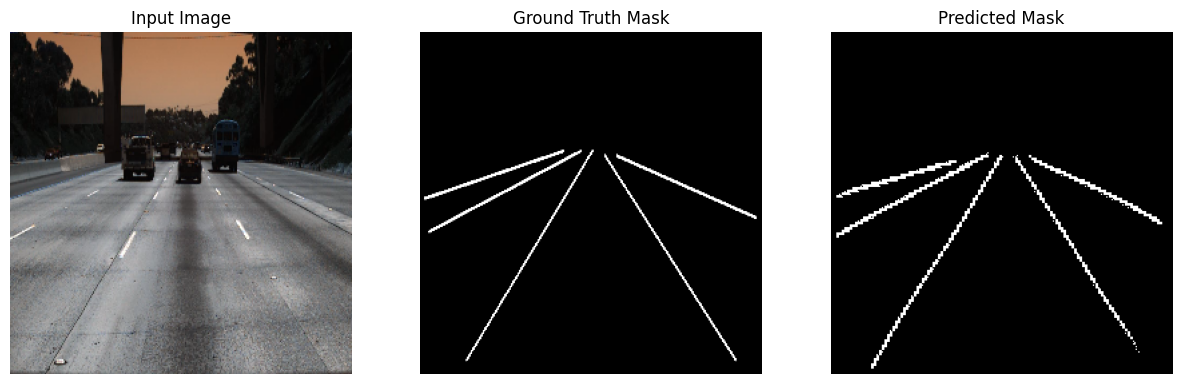

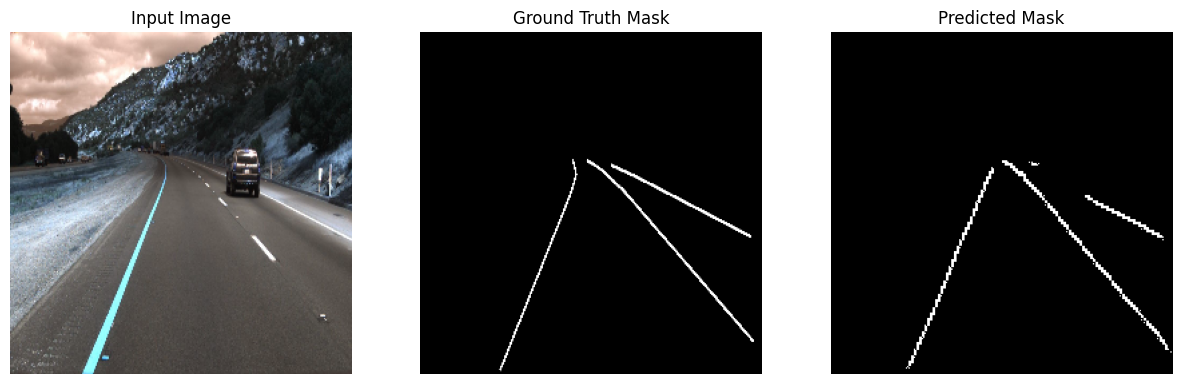

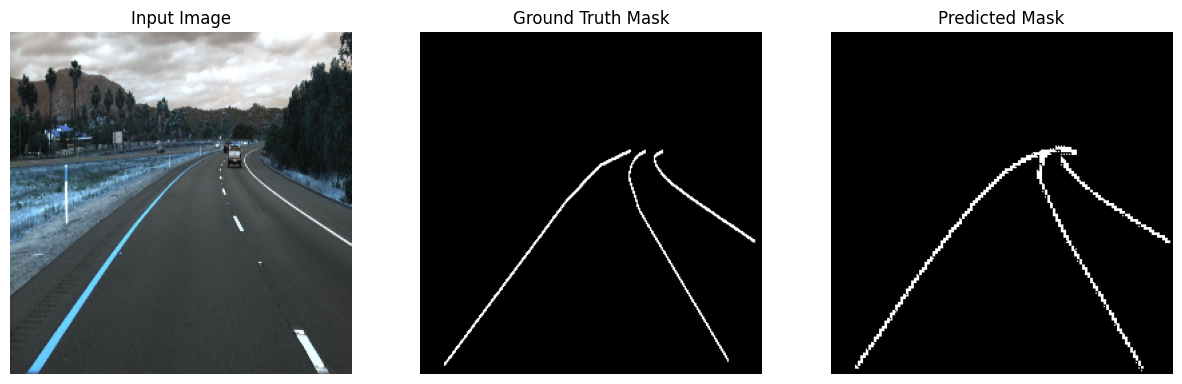

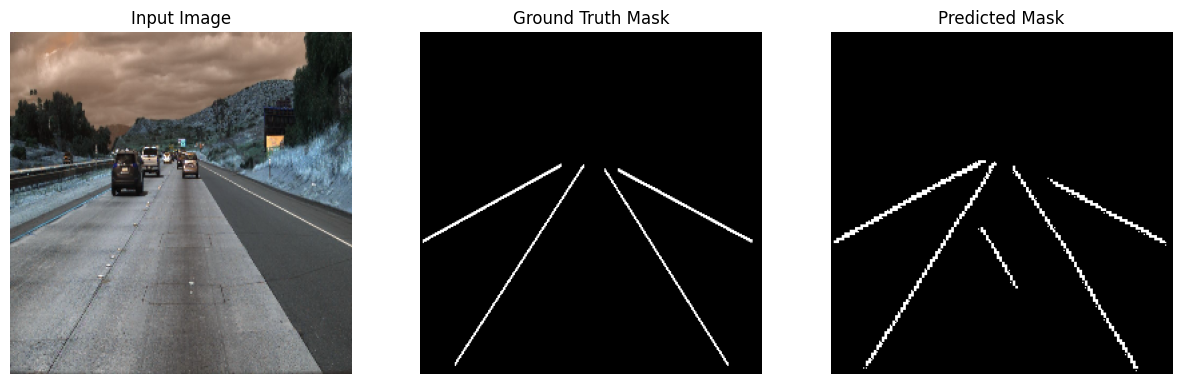

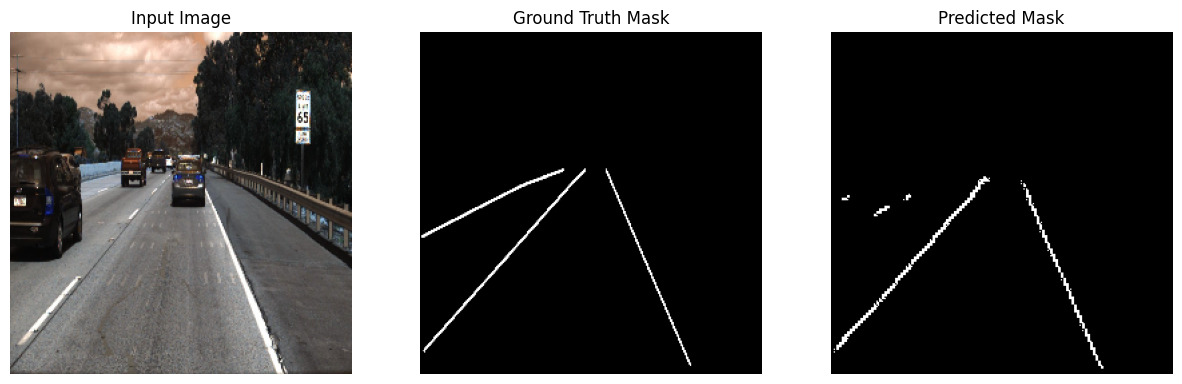

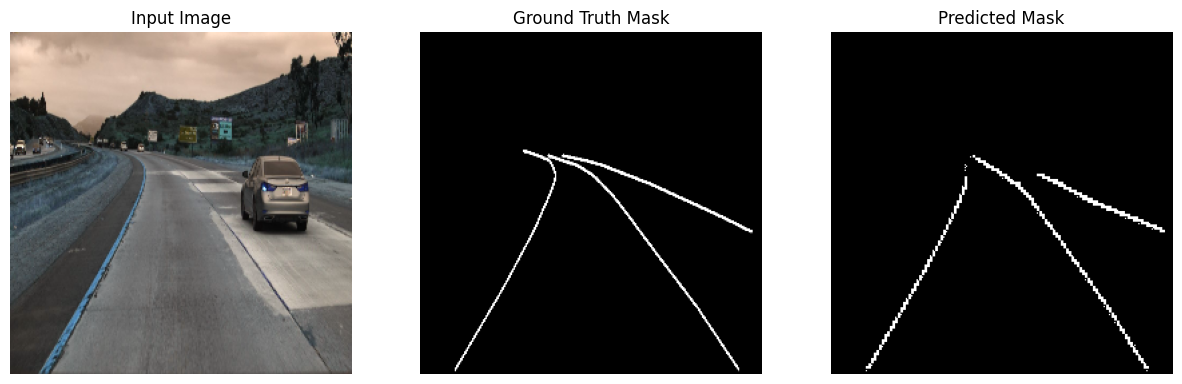

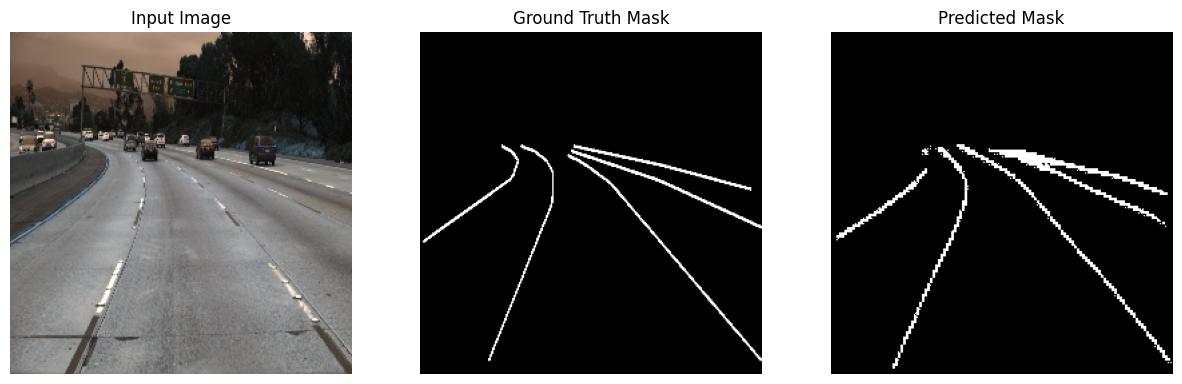

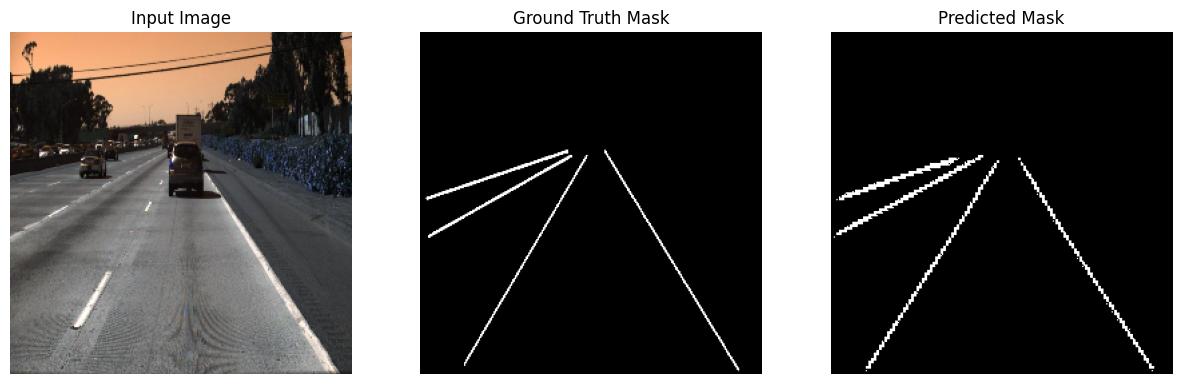

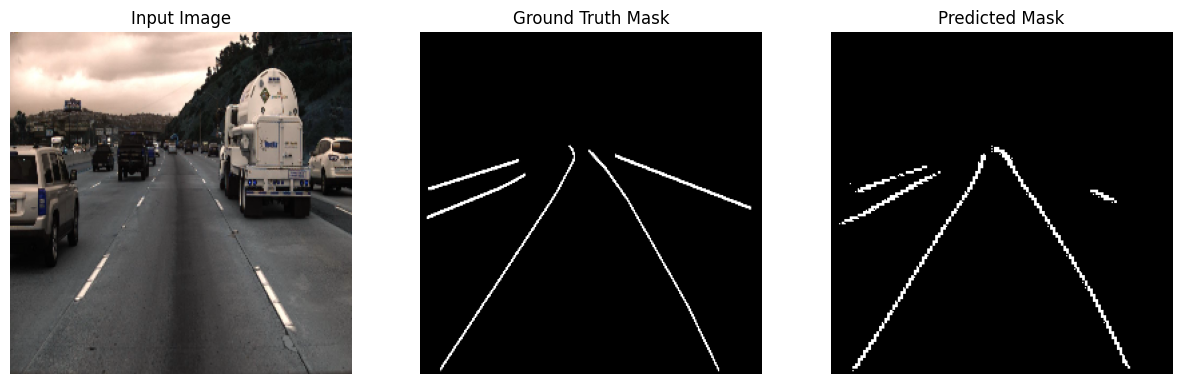

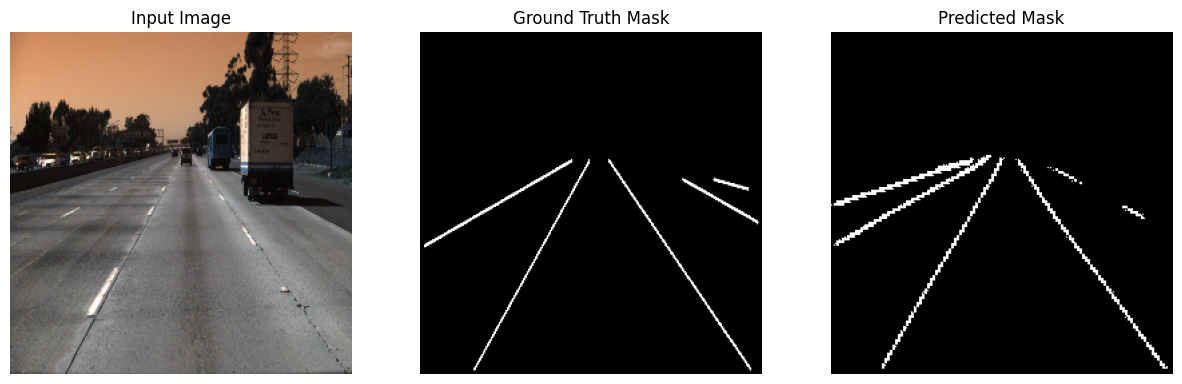

In [8]:
for i in range(10):
    input_image = x_test_raw[i]
    ground_truth = y_test_raw[i]
    display_result(input_image, ground_truth, model, device)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.load("efficientnet_full_model.pth", map_location=device, weights_only=False)
model.eval()

SimpleENet(
  (initial_block): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (encoder): Sequential(
    (0): Bottleneck(
      (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (residual_conv): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (residual_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (conv3): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [ ]:
# display pictures
def display_result(input_image, ground_truth, model, device):
    model_input = torch.from_numpy(input_image.transpose(2, 0, 1)).float().div(255.0).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(model_input)
    predicted_mask = output.squeeze().cpu().numpy()
    predicted_mask = (predicted_mask > 0.3).astype(np.uint8)
    predicted_mask *= 255
    
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
  
    axs[0].imshow(input_image)
    axs[0].set_title("Input Image")
    axs[0].axis('off')
    
   
    axs[1].imshow(ground_truth, cmap='gray')
    axs[1].set_title("Ground Truth Mask")
    axs[1].axis('off')
    
   
    axs[2].imshow(predicted_mask, cmap='gray')
    axs[2].set_title("Predicted Mask")
    axs[2].axis('off')
    
    plt.show()

In [ ]:
for i in range(10):
    input_image = x_test_raw[i]
    ground_truth = y_test_raw[i]
    display_result(input_image, ground_truth, model, device)

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def display_result_NEW(input_image, model, device, threshold=0.3):
    """
    Display input image and predicted mask only.
    input_image: numpy array (H, W, 3)
    model: trained PyTorch model
    device: 'cuda' or 'cpu'
    """
    # Prepare image tensor
    model_input = torch.from_numpy(input_image.transpose(2, 0, 1)).float().div(255.0).unsqueeze(0).to(device)

    # Model inference
    model.eval()
    with torch.no_grad():
        output = model(model_input)

    # Convert to numpy mask
    predicted_mask = output.squeeze().cpu().numpy()
    predicted_mask = (predicted_mask > threshold).astype(np.uint8) * 255

    # Display input and prediction
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(input_image)
    axs[0].set_title("Input Image")
    axs[0].axis('off')

    axs[1].imshow(predicted_mask, cmap='gray')
    axs[1].set_title("Predicted Mask")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()


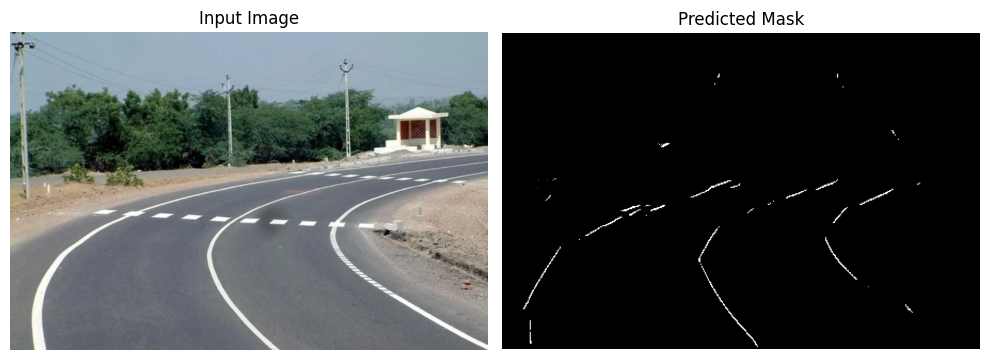

In [13]:
from PIL import Image
import numpy as np

input_image_path = './image.png'
input_image = np.array(Image.open(input_image_path).convert('RGB'))
display_result_NEW(input_image, model, device)